In [32]:
%cd /work/project/escience/ruttho/FCCee_HiggLFV

/work/project/escience/ruttho/FCCee_HiggLFV


In [ ]:
import pandas as pd
import os

def GetFinalAcceptance(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if "finalstate_nocut" in line:
                passEvt = int((line.split("(")[0].strip()).split(" ")[-1].strip())
                return passEvt
    return None

def GetThisCutTable(path, selection, data):
    data_key = data.keys()
    files = [f for f in sorted(os.listdir(path)) if f.endswith(".txt")]
    # bg_files = [f for f in files if "ISR" in f]
    # # print(bg_files)
    # HLFV_files = [f for f in files if f.startswith("HLFV")]
    # VBF_files = [f for f in files if f.startswith("VBF")]
    
    for a in files:
        if "ISR" in a:
            name = ("_".join(a.split("_")[1:-1]))
        elif a.startswith("HLFV"):
            name = ("_".join(["HZ"] + a.split("_")[1:-1]))
        elif a.startswith("VBF"):
            name = ("_".join(["VBF"] + a.split("_")[2:-1]))
        else:
            continue
        phsp = a.split("_")[-1][:-7]
        filepath = os.path.join(path, a)
        evtpass = GetFinalAcceptance(filepath)
        selection_name = "_".join([phsp, selection])
        if name in data_key:
            data[name][selection_name] = evtpass
        else:
            data[name] = {selection_name: evtpass}

    return data


# different number different from MassToPT
def diff_df(df_sorted_cols):
    df_diff = pd.DataFrame()
    for col in df_sorted_cols.columns:
        if "MasstoPT" in col:
            co_name = col.split("_")[0]
            for col2 in df_sorted_cols.columns:
                if co_name in col2 and "MasstoPT" not in col2:
                    df_diff[col2] = df_sorted_cols[col2] - df_sorted_cols[col]
    return df_diff

def diff_percent(df_sorted_cols):
    df_diff_percent = pd.DataFrame()
    for col in df_sorted_cols.columns:
        if "MasstoPT" in col:
            co_name = col.split("_")[0]
            for col2 in df_sorted_cols.columns:
                if co_name in col2 and "MasstoPT" not in col2:
                    df_diff_percent[col2] = (df_sorted_cols[col2] - df_sorted_cols[col]) / df_sorted_cols[col] * 100
    return df_diff_percent


process_types= os.listdir("Selections/")
All_Final_Acceptance = {}
for process in process_types: # mue, etaumu
    All_Final_Acceptance[process] = {}
    selection_types = os.listdir("Selections/"+process)
    for selection in selection_types: # MasstoPT, etc
        All_Final_Acceptance[process] = GetThisCutTable("Selections/"+process+"/"+selection+"/", selection, All_Final_Acceptance[process])


df_dict={ "MuE": pd.DataFrame(All_Final_Acceptance["MuE"]).T , "ETauMu": pd.DataFrame(All_Final_Acceptance["ETauMu"]).T }
df_sorted_cols = {key: df.sort_index(axis=1) for key, df in df_dict.items()}
pd.set_option('display.float_format', '{:.4f}'.format)
diff_percent_dict = {key: diff_percent(df) for key, df in df_sorted_cols.items()}
df_diff_dict = {key: diff_df(df) for key, df in df_sorted_cols.items()}

In [82]:
df_sorted_cols["MuE"]

,21To81_MasstoPT,21To81_OnlyPT,21To81_PTtoMass,81To101_MasstoPT,81To101_OnlyPT,81To101_PTtoMass
HZ_110GeV,25614,26016,26016,476098,479027,479027
HZ_115GeV,25528,25873,25873,474633,477120,477120
HZ_120GeV,24820,25201,25201,471895,473896,473896
HZ_125GeV,23980,24343,24343,470163,471745,471745
HZ_130GeV,23540,23901,23901,468237,469519,469519
HZ_135GeV,23436,23784,23784,465933,466913,466913
HZ_140GeV,25415,25801,25801,460815,461511,461511
HZ_145GeV,33448,33832,33832,452138,452605,452605
HZ_150GeV,126051,126625,126625,361391,361710,361710
HZ_155GeV,300340,301235,301235,187385,187398,187398


In [85]:
diff_percent_dict["ETauMu"]#.plot(kind="bar", figsize=(12, 6), title="Percentage Difference in Final Acceptance between MassToPT and OnlyPT for ETauMu")

,21To81_OnlyPT,21To81_PTtoMass,81To101_OnlyPT,81To101_PTtoMass
HZ_110GeV,-33.8660,-33.8660,-42.3640,-42.3640
HZ_115GeV,-33.4673,-33.4673,-42.0177,-42.0177
HZ_120GeV,-34.2403,-34.2403,-41.7035,-41.7035
HZ_125GeV,-33.4874,-33.4874,-41.3744,-41.3744
HZ_130GeV,-35.2816,-35.2816,-40.7889,-40.7889
HZ_135GeV,-35.8482,-35.8482,-40.0748,-40.0748
HZ_140GeV,-36.2569,-36.2569,-39.5289,-39.5289
HZ_145GeV,-36.3098,-36.3098,-38.4626,-38.4626
HZ_150GeV,-35.5111,-35.5111,-33.6425,-33.6425
HZ_155GeV,-33.3590,-33.3590,-15.3323,-15.3323


In [84]:
df_diff_dict["ETauMu"]#.plot(kind="bar", figsize=(12, 6), title="Difference in Final Acceptance between MassToPT and OnlyPT for ETauMu")

,21To81_OnlyPT,21To81_PTtoMass,81To101_OnlyPT,81To101_PTtoMass
HZ_110GeV,-6209,-6209,-155601,-155601
HZ_115GeV,-6079,-6079,-156637,-156637
HZ_120GeV,-6418,-6418,-157157,-157157
HZ_125GeV,-6377,-6377,-157925,-157925
HZ_130GeV,-6966,-6966,-157436,-157436
HZ_135GeV,-7479,-7479,-155901,-155901
HZ_140GeV,-8400,-8400,-153752,-153752
HZ_145GeV,-11280,-11280,-147987,-147987
HZ_150GeV,-42064,-42064,-98472,-98472
HZ_155GeV,-93468,-93468,-17888,-17888


In [4]:
def plot_difference_table(df_identifier, MuE_MassToPT, ETau_MassToPT, MuE_PTtoMass, ETau_PTtoMass):
    GetDifferenceTable(df_identifier, MuE_MassToPT, ETau_MassToPT, MuE_PTtoMass, ETau_PTtoMass).plot(kind='line', figsize=(10,6), title=f"Difference in Passed Events (MassToPT - PTtoMass) for {df_identifier}")

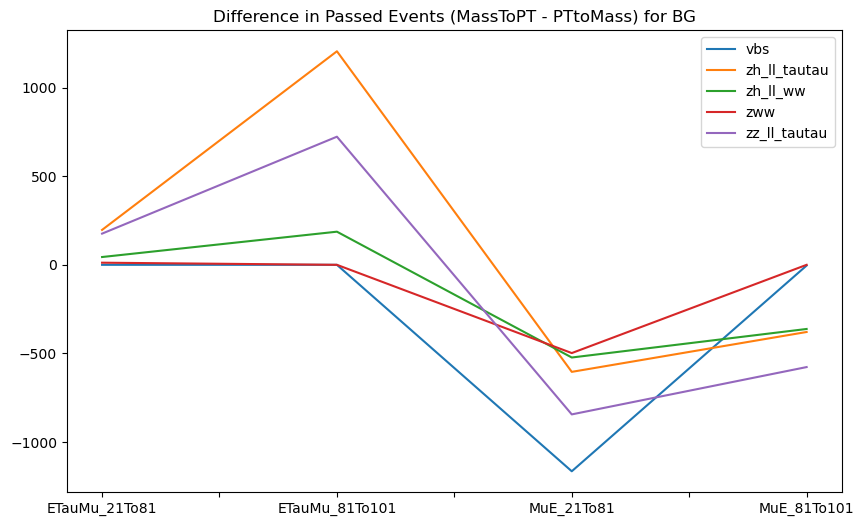

In [5]:
plot_difference_table("BG", MuE_MassToPT, ETau_MassToPT, MuE_PTtoMass, ETau_PTtoMass)

In [6]:
id="HZ"
df = pd.DataFrame({
        "MuE_PTtoMass" : MuE_PTtoMass[id],
        "MuE_MassToPT" : MuE_MassToPT[id],
        "ETau_PTtoMass" : ETau_PTtoMass[id],
        "ETau_MassToPT" : ETau_MassToPT[id],
    })
intermediate = pd.DataFrame({
        "MuE" : df["MuE_MassToPT"] - df["MuE_PTtoMass"],
        "ETauMu" : df["ETau_MassToPT"] - df["ETau_PTtoMass"]
    })
x=df.T[sorted([i for i in intermediate.T.keys() if "21" in i])].T
y=df.T[sorted([i for i in intermediate.T.keys() if "101" in i])].T

In [7]:
x

,MuE_PTtoMass,MuE_MassToPT,ETau_PTtoMass,ETau_MassToPT
HZ_110GeV_21To81,25960.0,25612.0,18005.0,18333.0
HZ_115GeV_21To81,25830.0,25526.0,17755.0,18161.0
HZ_120GeV_21To81,25148.0,24817.0,18362.0,18740.0
HZ_125GeV_21To81,24287.0,23977.0,18628.0,19043.0
HZ_130GeV_21To81,23836.0,23538.0,19303.0,19743.0
HZ_135GeV_21To81,23739.0,23434.0,20361.0,20862.0
HZ_140GeV_21To81,25751.0,25415.0,22640.0,23167.0
HZ_145GeV_21To81,33765.0,33443.0,30383.0,31061.0
HZ_150GeV_21To81,126536.0,126045.0,116057.0,118445.0
HZ_155GeV_21To81,301045.0,300329.0,274503.0,280172.0


In [8]:
z = pd.DataFrame({
    "MuE_21To81" : (x["MuE_PTtoMass"] - x["MuE_MassToPT"])*100/x["MuE_MassToPT"],
    "ETau_21To81" : (x["ETau_PTtoMass"] - x["ETau_MassToPT"])*100/x["ETau_MassToPT"]
})

In [9]:
z

,MuE_21To81,ETau_21To81
HZ_110GeV_21To81,1.358738,-1.789123
HZ_115GeV_21To81,1.190943,-2.235560
HZ_120GeV_21To81,1.333763,-2.017076
HZ_125GeV_21To81,1.292906,-2.179278
HZ_130GeV_21To81,1.266038,-2.228638
HZ_135GeV_21To81,1.301528,-2.401496
HZ_140GeV_21To81,1.322054,-2.274787
HZ_145GeV_21To81,0.962832,-2.182802
HZ_150GeV_21To81,0.389543,-2.016126
HZ_155GeV_21To81,0.238405,-2.023400


In [10]:
y

,MuE_PTtoMass,MuE_MassToPT,ETau_PTtoMass,ETau_MassToPT
HZ_110GeV_81To101,476499.0,476079.0,363997.0,367278.0
HZ_115GeV_81To101,474973.0,474617.0,369307.0,372771.0
HZ_120GeV_81To101,472168.0,471867.0,373417.0,376830.0
HZ_125GeV_81To101,470358.0,470145.0,378066.0,381692.0
HZ_130GeV_81To101,468432.0,468224.0,382370.0,385966.0
HZ_135GeV_81To101,466081.0,465914.0,385531.0,389011.0
HZ_140GeV_81To101,460922.0,460797.0,385244.0,388951.0
HZ_145GeV_81To101,452176.0,452125.0,381199.0,384746.0
HZ_150GeV_81To101,361415.0,361381.0,289870.0,292697.0
HZ_155GeV_81To101,187383.0,187378.0,115632.0,116666.0


In [11]:
b = pd.DataFrame({
    "MuE_81To101" : (y["MuE_PTtoMass"] - y["MuE_MassToPT"])*100/y["MuE_MassToPT"],
    "ETau_81To101" : (y["ETau_PTtoMass"] - y["ETau_MassToPT"])*100/y["ETau_MassToPT"]
})
b

,MuE_81To101,ETau_81To101
HZ_110GeV_81To101,0.088221,-0.893329
HZ_115GeV_81To101,0.075008,-0.929257
HZ_120GeV_81To101,0.063789,-0.905713
HZ_125GeV_81To101,0.045305,-0.949981
HZ_130GeV_81To101,0.044423,-0.931688
HZ_135GeV_81To101,0.035844,-0.894576
HZ_140GeV_81To101,0.027127,-0.953076
HZ_145GeV_81To101,0.011280,-0.921907
HZ_150GeV_81To101,0.009408,-0.965845
HZ_155GeV_81To101,0.002668,-0.886291


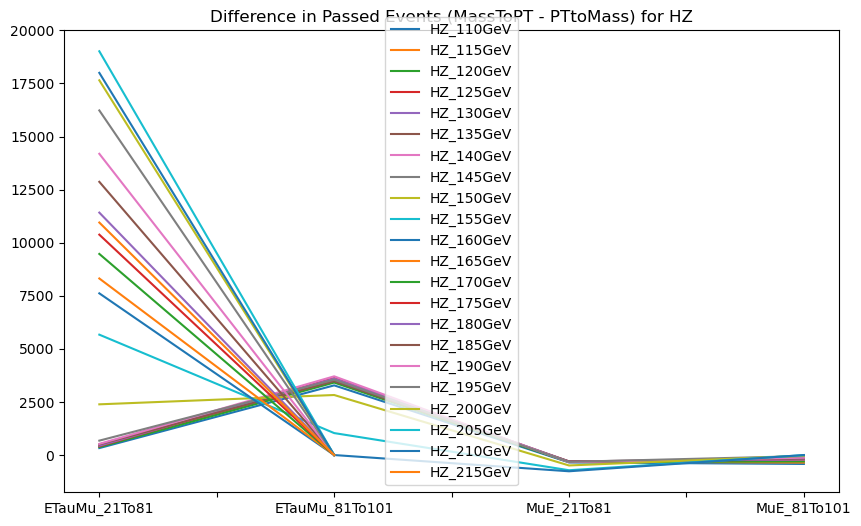

In [12]:
plot_difference_table("HZ", MuE_MassToPT, ETau_MassToPT, MuE_PTtoMass, ETau_PTtoMass)

In [13]:
df.T[[i for i in intermediate.T.keys() if "21" in i]].T

,MuE_PTtoMass,MuE_MassToPT,ETau_PTtoMass,ETau_MassToPT
HZ_110GeV_21To81,25960.0,25612.0,18005.0,18333.0
HZ_115GeV_21To81,25830.0,25526.0,17755.0,18161.0
HZ_120GeV_21To81,25148.0,24817.0,18362.0,18740.0
HZ_125GeV_21To81,24287.0,23977.0,18628.0,19043.0
HZ_130GeV_21To81,23836.0,23538.0,19303.0,19743.0
HZ_135GeV_21To81,23739.0,23434.0,20361.0,20862.0
HZ_140GeV_21To81,25751.0,25415.0,22640.0,23167.0
HZ_145GeV_21To81,33765.0,33443.0,30383.0,31061.0
HZ_150GeV_21To81,126536.0,126045.0,116057.0,118445.0
HZ_155GeV_21To81,301045.0,300329.0,274503.0,280172.0


In [14]:
id="BG"
df = pd.DataFrame({
        "MuE_MassToPT" : MuE_MassToPT[id],
        "ETau_MassToPT" : ETau_MassToPT[id],
        "MuE_PTtoMass" : MuE_PTtoMass[id],
        "ETau_PTtoMass" : ETau_PTtoMass[id]
    })
intermediate = pd.DataFrame({
        "MuE" : df["MuE_MassToPT"] - df["MuE_PTtoMass"],
        "ETauMu" : df["ETau_MassToPT"] - df["ETau_PTtoMass"]
    })
x=df.T[[i for i in intermediate.T.keys() if "21" in i]].T
y=df.T[[i for i in intermediate.T.keys() if "101" in i]].T

In [15]:
x

,MuE_MassToPT,ETau_MassToPT,MuE_PTtoMass,ETau_PTtoMass
vbs_21To81,89634,13979,90799,13979
zh_ll_tautau_21To81,8282,6948,8886,6751
zh_ll_ww_21To81,5148,2713,5671,2669
zww_21To81,193449,57563,193947,57551
zz_ll_tautau_21To81,6028,6746,6872,6570


In [16]:
y

,MuE_MassToPT,ETau_MassToPT,MuE_PTtoMass,ETau_PTtoMass
vbs_81To101,13662,1127,13666,1127
zh_ll_tautau_81To101,98909,132086,99288,130881
zh_ll_ww_81To101,90582,32990,90944,32803
zww_81To101,12681,4266,12681,4266
zz_ll_tautau_81To101,78942,113201,79519,112478


In [17]:
xx = pd.DataFrame({
    "MuE_21To81" : (x["MuE_PTtoMass"] - x["MuE_MassToPT"]),
    "ETau_21To81" : (x["ETau_PTtoMass"] - x["ETau_MassToPT"])
})
xx

,MuE_21To81,ETau_21To81
vbs_21To81,1165,0
zh_ll_tautau_21To81,604,-197
zh_ll_ww_21To81,523,-44
zww_21To81,498,-12
zz_ll_tautau_21To81,844,-176


In [18]:
yy = pd.DataFrame({
    "MuE_81To101" : (y["MuE_PTtoMass"] - y["MuE_MassToPT"]),
    "ETau_81To101" : (y["ETau_PTtoMass"] - y["ETau_MassToPT"])
})
yy

,MuE_81To101,ETau_81To101
vbs_81To101,4,0
zh_ll_tautau_81To101,379,-1205
zh_ll_ww_81To101,362,-187
zww_81To101,0,0
zz_ll_tautau_81To101,577,-723


In [19]:
xxx = pd.DataFrame({
    "MuE_21To81" : (x["MuE_PTtoMass"] - x["MuE_MassToPT"])*100/x["MuE_MassToPT"],
    "ETau_21To81" : (x["ETau_PTtoMass"] - x["ETau_MassToPT"])*100/x["ETau_MassToPT"]
})
xxx

,MuE_21To81,ETau_21To81
vbs_21To81,1.299730,0.000000
zh_ll_tautau_21To81,7.292924,-2.835348
zh_ll_ww_21To81,10.159285,-1.621821
zww_21To81,0.257432,-0.020847
zz_ll_tautau_21To81,14.001327,-2.608953


In [20]:
yyy = pd.DataFrame({
    "MuE_81To101" : (y["MuE_PTtoMass"] - y["MuE_MassToPT"])*100/y["MuE_MassToPT"],
    "ETau_81To101" : (y["ETau_PTtoMass"] - y["ETau_MassToPT"])*100/y["ETau_MassToPT"]
})
yyy

,MuE_81To101,ETau_81To101
vbs_81To101,0.029278,0.000000
zh_ll_tautau_81To101,0.383180,-0.912284
zh_ll_ww_81To101,0.399638,-0.566838
zww_81To101,0.000000,0.000000
zz_ll_tautau_81To101,0.730916,-0.638687
